In [29]:
from sklearn import datasets
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from io import BytesIO
from PIL import Image
import base64
import numpy as np
import umap
%matplotlib inline

https://umap-learn.readthedocs.io/en/latest/basic_usage.html#digits-data

In [19]:
sns.set(style='white', context='notebook', rc={'figure.figsize':(14,10)})

First we will load the dataset from sklearn.

In [42]:
digits = datasets.load_digits()
#print(digits.DESCR)
print(digits.images.shape)
digits.images[0,:,:]

(1797, 8, 8)


array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

We can plot a number of the images to get an idea of what we are looking at. This just involves matplotlib building a grid of axes and then looping through them plotting an image into each one in turn.

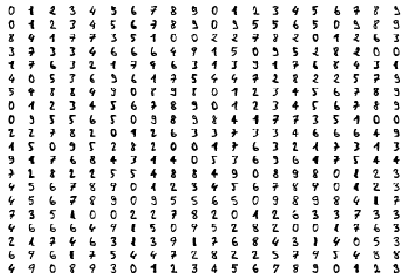

In [11]:
fig, ax_array = plt.subplots(20, 20)
axes = ax_array.flatten()
for i, ax in enumerate(axes):
    ax.imshow(digits.images[i], cmap='gray_r')
plt.setp(axes, xticks=[], yticks=[], frame_on=False)
plt.tight_layout(h_pad=0.5, w_pad=0.01)

As you can see these are quite low resolution images – for the most part they are recognisable as digits, but there are a number of cases that are sufficiently blurred as to be questionable even for a human to guess at. The zeros do stand out as the easiest to pick out as notably different and clearly zeros. Beyond that things get a little harder: some of the squashed thing eights look awfully like ones, some of the threes start to look a little like crossed sevens when drawn badly, and so on.

Each image can be unfolded into a 64 element long vector of grayscale values. It is these 64 dimensional vectors that we wish to analyse: how much of the digits structure can we discern? At least in principle 64 dimensions is overkill for this task, and we would reasonably expect that there should be some smaller number of “latent” features that would be sufficient to describe the data reasonably well. We can try a scatterplot matrix – in this case just of the first 10 dimensions so that it is at least plottable, but as you can quickly see that approach is not going to be sufficient for this data.

D:\Installed\Anaconda\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval
D:\Installed\Anaconda\lib\site-packages\statsmodels\nonparametric\kde.py:488: RuntimeWarning: invalid value encountered in true_divide
  binned = fast_linbin(X, a, b, gridsize) / (delta * nobs)
D:\Installed\Anaconda\lib\site-packages\statsmodels\nonparametric\kdetools.py:34: RuntimeWarning: invalid value encountered in double_scalars
  FAC1 = 2*(np.pi*bw/RANGE)**2


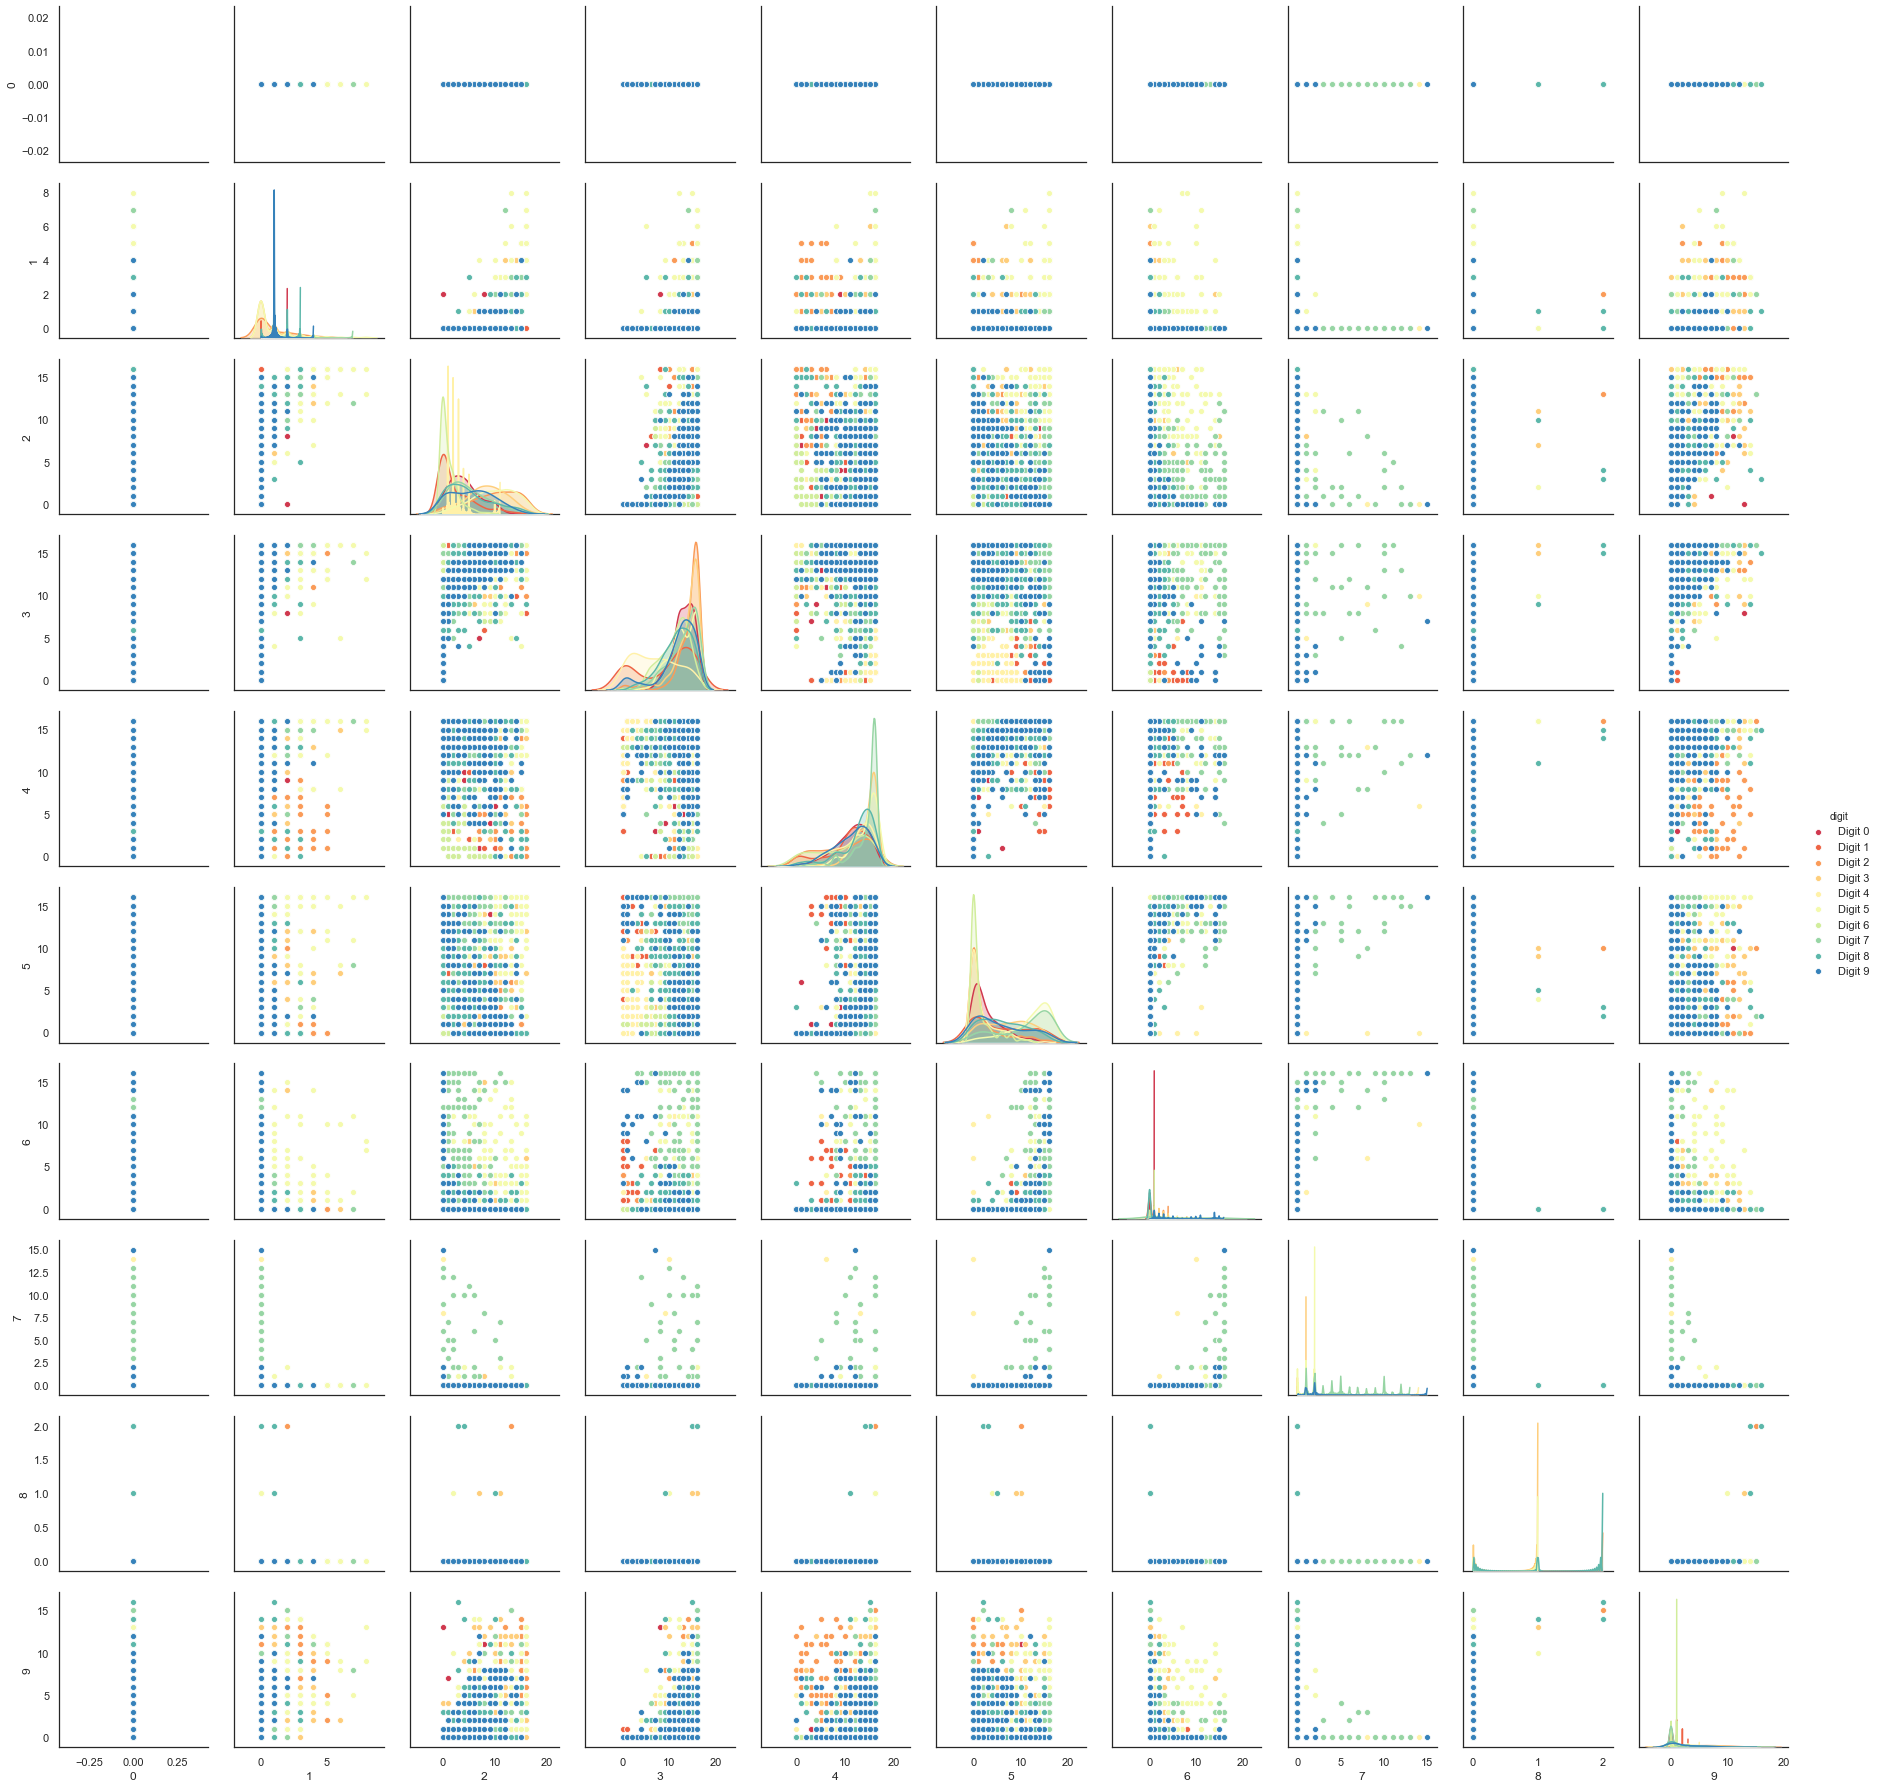

In [43]:
digits_df = pd.DataFrame(digits.data[:,:10])
digits_df['digit'] = pd.Series(digits.target).map(lambda x: 'Digit {}'.format(x))

sns.pairplot(digits_df, hue='digit', palette='Spectral');

In contrast we can try using UMAP again. It works exactly as before: construct a model, train the model, and then look at the transformed data. TO demonstrate more of UMAP we’ll go about it differently this time and simply use the fit method rather than the fit_transform approach we used for Iris.

In [22]:
reducer = umap.UMAP(random_state=42)
reducer.fit(digits.data)

UMAP(a=None, angular_rp_forest=False, b=None, init='spectral',
     learning_rate=1.0, local_connectivity=1.0, metric='euclidean',
     metric_kwds=None, min_dist=0.1, n_components=2, n_epochs=None,
     n_neighbors=15, negative_sample_rate=5, random_state=42,
     repulsion_strength=1.0, set_op_mix_ratio=1.0, spread=1.0,
     target_metric='categorical', target_metric_kwds=None,
     target_n_neighbors=-1, target_weight=0.5, transform_queue_size=4.0,
     transform_seed=42, verbose=False)

(1797, 64)

Now, instead of returning an embedding we simply get back the reducer object, now having trained on the dataset we passed it. To access the resulting transform we can either look at the embedding_ attribute of the reducer object, or call transform on the original data.

In [23]:
embedding = reducer.transform(digits.data)
# Verify that the result of calling transform is
# idenitical to accessing the embedding_ attribute
assert(np.all(embedding == reducer.embedding_))
embedding.shape

(1797, 2)

We now have a dataset with 1797 rows (one for each hand-written digit sample), but only 2 columns. As with the Iris example we can now plot the resulting embedding, coloring the data points by the class that theyr belong to (i.e. the digit they represent).

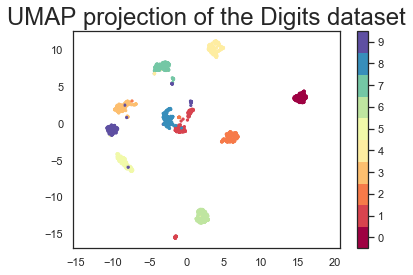

In [24]:
plt.scatter(embedding[:, 0], embedding[:, 1], c=digits.target, cmap='Spectral', s=5)
plt.gca().set_aspect('equal', 'datalim')
plt.colorbar(boundaries=np.arange(11)-0.5).set_ticks(np.arange(10))
plt.title('UMAP projection of the Digits dataset', fontsize=24);

We see that UMAP has successfully captured the digit classes. There are also some interesting effects as some digit classes blend into one another (see the eights, ones, and sevens, with some nines in between), and also cases where digits are pushed away as clearly distinct (the zeros on the right, the fours at the top, and a small subcluster of ones at the bottom come to mind). To get a better idea of why UMAP chose to do this it is helpful to see the actual digits involve. One can do this using bokeh and mouseover tooltips of the images.

First we’ll need to encode all the images for inclusion in a dataframe.

In [25]:
def embeddable_image(data):
    img_data = 255 - 15 * data.astype(np.uint8)
    image = Image.fromarray(img_data, mode='L').resize((64, 64), Image.BICUBIC)
    buffer = BytesIO()
    image.save(buffer, format='png')
    for_encoding = buffer.getvalue()
    return 'data:image/png;base64,' + base64.b64encode(for_encoding).decode()

Next we need to load up bokeh and the various tools from it that will be needed to generate a suitable interactive plot.

In [26]:
from bokeh.plotting import figure, show, output_notebook
from bokeh.models import HoverTool, ColumnDataSource, CategoricalColorMapper
from bokeh.palettes import Spectral10

output_notebook()

Loading BokehJS ...

Finally we generate the plot itself with a custom hover tooltip that embeds the image of the digit in question in it, along with the digit class that the digit is actually from (this can be useful for digits that are hard even for humans to classify correctly).

In [95]:
digits_df = pd.DataFrame(embedding, columns=('x', 'y'))
digits_df['digit'] = [str(x) for x in digits.target]
digits_df['image'] = list(map(embeddable_image, digits.images))

datasource = ColumnDataSource(digits_df)
color_mapping = CategoricalColorMapper(factors=[str(9 - x) for x in digits.target_names],
                                       palette=Spectral10)

plot_figure = figure(
    title='UMAP projection of the Digits dataset',
    plot_width=600,
    plot_height=600,
    tools=('pan, wheel_zoom, reset')
)

plot_figure.add_tools(HoverTool(tooltips="""
<div>
    <div>
        <img src='@image' style='float: left; margin: 5px 5px 5px 5px'/>
    </div>
    <div>
        <span style='font-size: 16px; color: #224499'>Digit:</span>
        <span style='font-size: 18px'>@digit</span>
    </div>
</div>
"""))

plot_figure.circle(
    'x',
    'y',
    source=datasource,
    color=dict(field='digit', transform=color_mapping),
    line_alpha=0.6,
    fill_alpha=0.6,
    size=4
)
show(plot_figure)


As can be seen, the nines that blend between the ones and the sevens are odd looking nines (that aren’t very rounded) and do, indeed, interpolate surprisingly well between ones with hats and crossed sevens. In contrast the small disjoint cluster of ones at the bottom of the plot is made up of ones with feet (a horizontal line at the base of the one) which are, indeed, quite distinct from the general mass of ones.

This concludes our introduction to basic UMAP usage – hopefully this has given you the tools to get started for yourself. Further tutorials, covering UMAP parameters and more advanced usage are also available when you wish to dive deeper.

**HDBSCAN**

In [107]:
import hdbscan
from sklearn.datasets import make_blobs
from sklearn.decomposition import PCA
from sklearn.datasets import fetch_openml

Robust Single Linkage

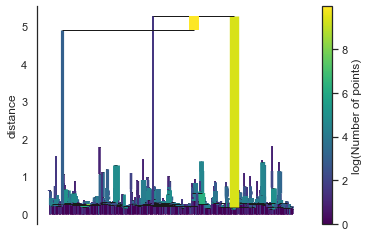

In [64]:
clusterer = hdbscan.RobustSingleLinkage(cut=0.125, k=7)
cluster_labels = clusterer.fit_predict(data)
hierarchy = clusterer.cluster_hierarchy_
alt_labels = hierarchy.get_clusters(0.100, 5)
hierarchy.plot()

**UMAP + HDBSCAN**
https://umap-learn.readthedocs.io/en/latest/clustering.html

In [146]:
sns.set(style='white', rc={'figure.figsize':(10,8)})

Our goal is to make use of UMAP to perform non-linear manifold aware dimension reduction so we can get the dataset down to a number of dimensions small enough for a density based clustering algorithm to make progress. One advantage of UMAP for this is that it doesn’t require you to reduce to only two dimensions – you can reduce to 10 dimensions instead since the goal is to cluster, not visualize, and the performance cost with UMAP is minimal. As it happens MNIST is such a simple dataset that we really can push it all the way down to only two dimensions, but in general you should explore different embedding dimension options.

The next thing to be aware of is that when using UMAP for dimension reduction you will want to select different parameters than if you were using it for visualization. First of all we will want a larger n_neighbors value – small values will focus more on very local structure and are more prone to producing fine grained cluster structure that may be more a result of patterns of noise in the data than actual clusters. In this case we’ll double it from the default 15 up to 30. Second it is beneficial to set min_dist to a very low value. Since we actually want to pack points together densely (density is what we want after all) a low value will help, as well as making cleaner separations between clusters. In this case we will simply set min_dist to be 0.

In [176]:
np.shape(digits.data)

(1797, 64)

We can visualize the results of this so see how it compares with more visualization attuned parameters:

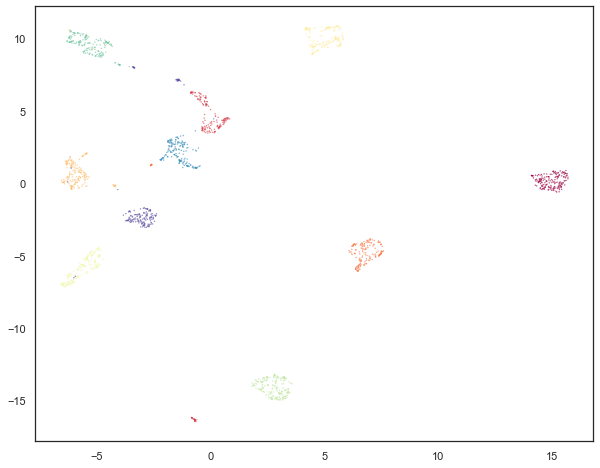

In [177]:
standard_embedding = umap.UMAP(random_state=41).fit_transform(digits.data)
plt.scatter(standard_embedding[:, 0], standard_embedding[:, 1], c=digits.target, s=0.1, cmap='Spectral');

In [143]:
clusterable_embedding = umap.UMAP(
    n_neighbors=30,
    min_dist=0.0,
    n_components=2,
    random_state=42,
).fit_transform(digits.data)

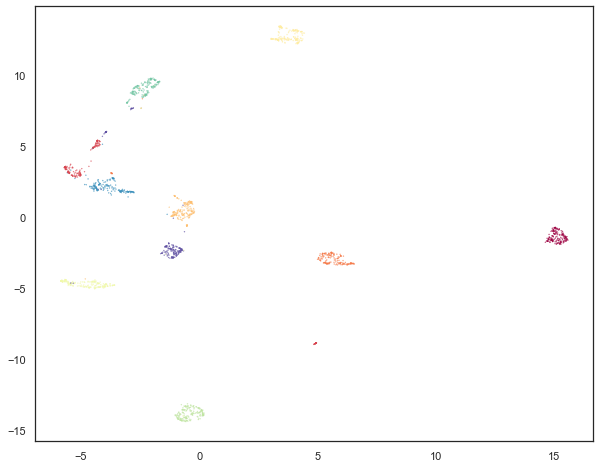

In [156]:
plt.scatter(clusterable_embedding[:, 0], clusterable_embedding[:, 1],
            c=digits.target, s=0.1, cmap='Spectral');

As you can see we still have the general global structure, but we are packing points together more tightly within clusters, and consequently we can see larger gaps between the clusters. Ultimately this embedding was for clustering purposes only, and we will go back to the original embedding for visualization purposes from here on out.

The next step is to cluster this data. We’ll use HDBSCAN again, with the same parameter setting as before.

In [167]:
labels = hdbscan.HDBSCAN(
    min_samples=10,
    min_cluster_size=50,
).fit_predict(clusterable_embedding)

And now we can visualize the results, just as before.

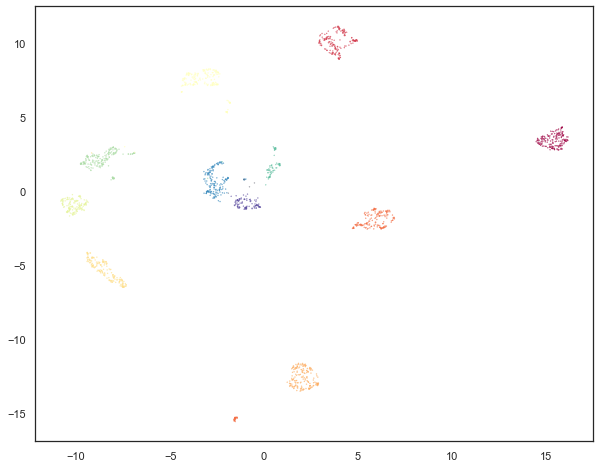

In [172]:
clustered = (labels >= 0)
plt.scatter(standard_embedding[~clustered, 0],
            standard_embedding[~clustered, 1],
            c=(0.5, 0.5, 0.5),
            s=0.1,
            alpha=0.5)

plt.scatter(standard_embedding[clustered, 0],
            standard_embedding[clustered, 1],
            c=labels[clustered],
            s=0.1,
            cmap='Spectral');

In [173]:
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score
adjusted_rand_score(digits.target, labels), adjusted_mutual_info_score(digits.target, labels)

(0.8811974369768325, 0.890133165021277)

In [174]:
clustered = (labels >= 0)
(
    adjusted_rand_score(digits.target[clustered], labels[clustered]),
    adjusted_mutual_info_score(digits.target[clustered], labels[clustered])
)

(0.8828645908000337, 0.8937433663914867)